In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


2026-05-20 20:12:34.004898: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-20 20:12:35.130003: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-20 20:12:39.720840: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
x = np.random.randint(-40,40,size=(1000,64))
y = np.reshape([i[0]*3+i[1]*4 for i in x],shape=(-1,1))
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [3]:
model = Sequential([
    
    Dense(32, activation='relu', input_shape=(64,)),
    Dense(1, activation='sigmoid'),
])

# Compilação
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

# Resumo
model.summary()



/home/davidsales/miniconda3/envs/corepy/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-20 20:12:45.553570: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,113 (8.25 KB)

 Trainable params: 2,113 (8.25 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Treinamento
model.fit(
    x_train, y_train,
    epochs=1000,
    validation_split=0.2,
    verbose=1
)

Epoch 1/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 13017.0801 - mae: 94.4408 - val_loss: 12271.0771 - val_mae: 88.7046
Epoch 2/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 13005.3232 - mae: 94.3982 - val_loss: 12264.5928 - val_mae: 88.6859
Epoch 3/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 12998.3545 - mae: 94.3712 - val_loss: 12263.6240 - val_mae: 88.6908
Epoch 4/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 12994.6055 - mae: 94.3543 - val_loss: 12262.7959 - val_mae: 88.6880
Epoch 5/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 12991.1123 - mae: 94.3391 - val_loss: 12261.3164 - val_mae: 88.6774
Epoch 6/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 12984.0576 - mae: 94.3163 - val_loss: 12259.8848 - val_mae: 88.6752
Epoch 7/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 12977.5557 - mae: 94.2897 - val_loss: 12259.5059 - val_mae: 88.6748
Epoch 8/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 12974.7734 - mae: 94.2746 - val_loss: 1225

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


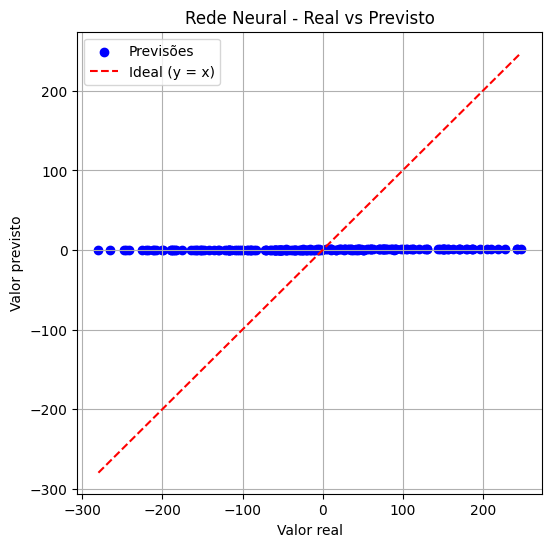

In [5]:
y_pred = model.predict(x_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, color='blue', label='Previsões')
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--',
    label='Ideal (y = x)'
)

plt.xlabel("Valor real")
plt.ylabel("Valor previsto")
plt.title("Rede Neural - Real vs Previsto")
plt.legend()
plt.grid()

plt.show()

In [8]:
item = [0]*64
item[0]=1
item[1]=.5
model.predict(np.array([item]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step


array([[0.86983]], dtype=float32)

In [ ]:
weights = model.weights

FRAC = 16
SCALE = 1 << FRAC

INT32_MAX = 2**31 - 1
INT32_MIN = -(2**31)


#Transforma float para Q16
def float_to_q16(val):
    if np.isnan(val):
        return 0
    if np.isposinf(val):
        return INT32_MAX
    if np.isneginf(val):
        return INT32_MIN

    fixed = int(np.round(val * SCALE))
    return max(INT32_MIN, min(INT32_MAX, fixed))

# Endereço: [layer(3 bits)][is_bias(1 bit)][neuron(4 bits)][input_idx(4 bits)]
def build_addr(layer, is_bias, neuron, idx):
    return (layer << 9) | (is_bias << 8) | (neuron << 4) | idx

# Export mem
mem = {}

layer_idx = 0
i = 0

while i < len(weights):

    kernel = weights[i].numpy().T
    bias   = weights[i+1].numpy()

    n_neurons, n_inputs = kernel.shape

    #Peso
    for n in range(n_neurons):
        for inp in range(n_inputs):

            if n >= 16 or inp >= 16:
                raise ValueError("Excedeu limite de 4 bits")

            addr = build_addr(layer_idx, 0, n, inp)
            mem[addr] = float_to_q16(kernel[n][inp])

    #Viés
    for n in range(n_neurons):

        if n >= 16:
            raise ValueError("Excedeu limite de 4 bits")

        addr = build_addr(layer_idx, 1, n, 0)
        mem[addr] = float_to_q16(bias[n])

    layer_idx += 1
    i += 2



max_addr = max(mem.keys())

with open("weights.mem", "w") as f:
    for addr in range(max_addr + 1):
        val = mem.get(addr, 0)

        # two's complement se negativo
        if val < 0:
            val = (1 << 32) + val

        f.write(f"{val:08x}\n")

print("Arquivo salvo: weights.mem")

Arquivo salvo: weights.mem


In [7]:
import numpy as np

weights = model.weights

FRAC = 16
SCALE = 1 << FRAC

INT32_MAX = 2**31 - 1
INT32_MIN = -(2**31)

# ============================================================
# FLOAT -> Q16.16
# ============================================================

def float_to_q16(val):

    if np.isnan(val):
        return 0

    if np.isposinf(val):
        return INT32_MAX

    if np.isneginf(val):
        return INT32_MIN

    fixed = int(np.round(val * SCALE))

    return max(INT32_MIN, min(INT32_MAX, fixed))

# ============================================================
# ADDRESS FORMAT
#
# [31:24] -> layer
# [23]    -> is_bias
# [22]    -> is_lstm
# [21:20] -> gate
# [19:10] -> neuron
# [9]     -> recurrent
# [8:0]   -> idx
# ============================================================

def build_addr(
    layer,
    is_bias,
    is_lstm,
    gate,
    neuron,
    recurrent,
    idx
):

    addr = 0

    addr |= (layer      & 0xFF) << 24
    addr |= (is_bias    & 0x1 ) << 23
    addr |= (is_lstm    & 0x1 ) << 22
    addr |= (gate       & 0x3 ) << 20
    addr |= (neuron     & 0x3FF) << 10
    addr |= (recurrent  & 0x1 ) << 9
    addr |= (idx        & 0x1FF)

    return addr

# ============================================================
# EXPORT
# ============================================================

mem = {}

layer_idx = 0
i = 0

while i < len(weights):

    kernel = weights[i].numpy().T
    bias   = weights[i + 1].numpy()

    n_neurons, n_inputs = kernel.shape

    # ========================================================
    # WEIGHTS
    # ========================================================

    for n in range(n_neurons):

        for inp in range(n_inputs):

            addr = build_addr(
                layer      = layer_idx,
                is_bias    = 0,
                is_lstm    = 0,
                gate       = 0,
                neuron     = n,
                recurrent  = 0,
                idx        = inp
            )

            mem[addr] = float_to_q16(kernel[n][inp])

    # ========================================================
    # BIASES
    # ========================================================

    for n in range(n_neurons):

        addr = build_addr(
            layer      = layer_idx,
            is_bias    = 1,
            is_lstm    = 0,
            gate       = 0,
            neuron     = n,
            recurrent  = 0,
            idx        = 0
        )

        mem[addr] = float_to_q16(bias[n])

    layer_idx += 1
    i += 2

# ============================================================
# WRITE FILE
# ============================================================

with open("weights.mem", "w") as f:

    for addr in sorted(mem.keys()):

        val = mem[addr]

        # two's complement
        if val < 0:
            val = (1 << 32) + val

        f.write(f"{addr:08x} {val:08x}\n")

print("Arquivo salvo: weights.mem")

Arquivo salvo: weights.mem
